In [4]:
from pathlib import Path
import sys, site
import torch
import numpy as np

# paths
BASE = Path.home() / "MyWork" / "LoRA_Reproduction"
LOGS_DIR = BASE / "results" / "logs"

# fix peft
USER_SITE = site.getusersitepackages()
if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

# imports
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from peft import LoraConfig, get_peft_model, TaskType

print("Setup done")

Setup done


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_thunder-0.2.2.dev0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.14.3-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/looseversion-1.3.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/nvfuser-0.2.27a0+5111d3b-py3.12-linux-x86_64.eg

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "nyu-mll/glue",
    "stsb",
    trust_remote_code=True
)

print(dataset)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nyu-mll/glue' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 5749
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1500
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx'],
        num_rows: 1379
    })
})


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["sentence1"],
        batch["sentence2"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

# IMPORTANT — keep labels as float
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("Tokenization done")

Tokenization done


In [5]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=1   # ❗ VERY IMPORTANT
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, lora_config)
model.to("cuda")

model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 886,273 || all params: 125,532,674 || trainable%: 0.7060


In [6]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = logits.squeeze()   # remove extra dimension

    pearson = pearsonr(preds, labels)[0]
    spearman = spearmanr(preds, labels)[0]

    return {
        "pearson": pearson,
        "spearman": spearman
    }

In [4]:
from pathlib import Path
from transformers import TrainingArguments

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"

training_args = TrainingArguments(
    output_dir=str(BASE / "nlu" / "stsb" / "output"),

    learning_rate=5e-4,
    num_train_epochs=10,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="pearson",   # ❗ IMPORTANT
    greater_is_better=True,

    report_to="none"
)

Tokenization done


In [8]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=1   # ❗ VERY IMPORTANT
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, lora_config)
model.to("cuda")

model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 886,273 || all params: 125,532,674 || trainable%: 0.7060


In [9]:
import numpy as np
from scipy.stats import pearsonr, spearmanr

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = logits.squeeze()   # remove extra dimension

    pearson = pearsonr(preds, labels)[0]
    spearman = spearmanr(preds, labels)[0]

    return {
        "pearson": pearson,
        "spearman": spearman
    }

In [10]:
from pathlib import Path
from transformers import TrainingArguments

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"

training_args = TrainingArguments(
    output_dir=str(BASE / "nlu" / "stsb" / "output"),

    learning_rate=5e-4,
    num_train_epochs=10,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="pearson",   # ❗ IMPORTANT
    greater_is_better=True,

    report_to="none"
)

In [11]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [12]:
model.config.use_cache = False
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Pearson,Spearman
1,0.733476,0.740577,0.885718,0.887457
2,0.449671,0.492827,0.894112,0.891833
3,0.446938,0.565653,0.899365,0.898316
4,0.308334,0.452561,0.901979,0.899703
5,0.314641,0.416388,0.905429,0.902756
6,0.304387,0.449067,0.905936,0.903523
7,0.348964,0.392044,0.908779,0.903293
8,0.259676,0.424327,0.907944,0.904339
9,0.283523,0.412070,0.907267,0.905126
10,0.235339,0.410570,0.908434,0.905390


TrainOutput(global_step=3600, training_loss=0.4201838714877764, metrics={'train_runtime': 211.5306, 'train_samples_per_second': 271.781, 'train_steps_per_second': 17.019, 'total_flos': 3820660699130880.0, 'train_loss': 0.4201838714877764, 'epoch': 10.0})

In [13]:
import json

metrics = trainer.evaluate()

results = {
    "task": "STS-B",
    "pearson": float(metrics["eval_pearson"]),
    "spearman": float(metrics["eval_spearman"])
}

LOGS_DIR = BASE / "results" / "logs"

with open(LOGS_DIR / "stsb_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("STS-B saved!")

Training Loss,Validation Loss,Epoch,Pearson,Spearman
0.235339,0.392044,10,0.908779,0.903293


STS-B saved!


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

RESULTS_DIR = Path.cwd() / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

epochs = list(range(1, 11))

training_loss = [
    0.733476,
    0.449671,
    0.446938,
    0.308334,
    0.314641,
    0.304387,
    0.348964,
    0.259676,
    0.283523,
    0.235339,
]

validation_loss = [
    0.740577,
    0.492827,
    0.565653,
    0.452561,
    0.416388,
    0.449067,
    0.392044,
    0.424327,
    0.412070,
    0.410570,
]

pearson_scores = [
    0.885718,
    0.894112,
    0.899365,
    0.901979,
    0.905429,
    0.905936,
    0.908779,
    0.907944,
    0.907267,
    0.908434,
]

spearman_scores = [
    0.887457,
    0.891833,
    0.898316,
    0.899703,
    0.902756,
    0.903523,
    0.903293,
    0.904339,
    0.905126,
    0.905390,
]

results_df = pd.DataFrame({
    "epoch": epochs,
    "training_loss": training_loss,
    "validation_loss": validation_loss,
    "pearson": pearson_scores,
    "spearman": spearman_scores,
})

display(results_df)

,epoch,training_loss,validation_loss,pearson,spearman
0,1,0.733476,0.740577,0.885718,0.887457
1,2,0.449671,0.492827,0.894112,0.891833
2,3,0.446938,0.565653,0.899365,0.898316
3,4,0.308334,0.452561,0.901979,0.899703
4,5,0.314641,0.416388,0.905429,0.902756
5,6,0.304387,0.449067,0.905936,0.903523
6,7,0.348964,0.392044,0.908779,0.903293
7,8,0.259676,0.424327,0.907944,0.904339
8,9,0.283523,0.412070,0.907267,0.905126
9,10,0.235339,0.410570,0.908434,0.905390


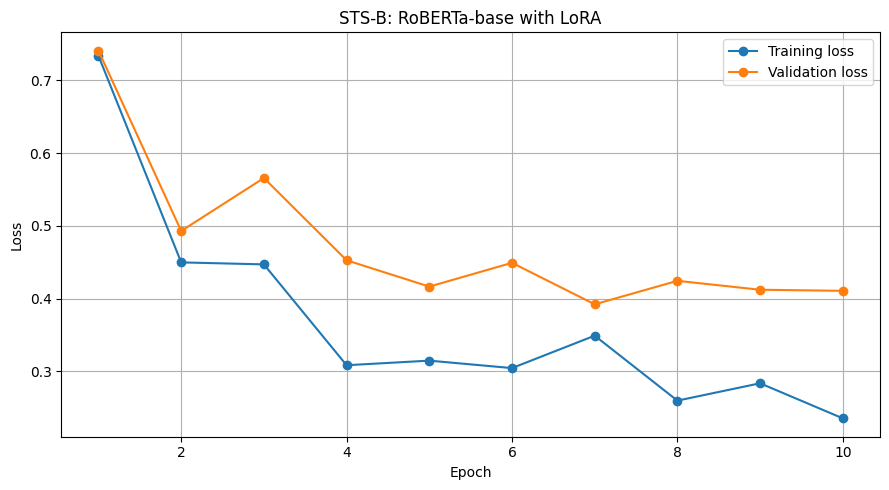

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/stsb_loss_curve.png


In [3]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss",
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("STS-B: RoBERTa-base with LoRA")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "stsb_loss_curve.png"

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", loss_plot_path)

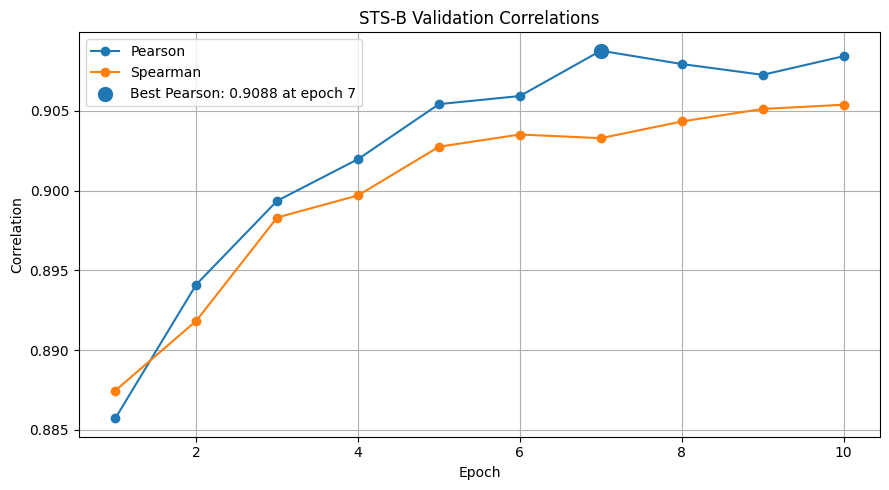

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/stsb_correlation_curve.png


In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    pearson_scores,
    marker="o",
    label="Pearson",
)

plt.plot(
    epochs,
    spearman_scores,
    marker="o",
    label="Spearman",
)

best_pearson_epoch = epochs[
    pearson_scores.index(max(pearson_scores))
]

best_pearson = max(pearson_scores)
best_spearman = max(spearman_scores)

plt.scatter(
    [best_pearson_epoch],
    [best_pearson],
    s=100,
    label=(
        f"Best Pearson: {best_pearson:.4f} "
        f"at epoch {best_pearson_epoch}"
    ),
)

plt.xlabel("Epoch")
plt.ylabel("Correlation")
plt.title("STS-B Validation Correlations")
plt.legend()
plt.grid(True)
plt.tight_layout()

metrics_plot_path = RESULTS_DIR / "stsb_correlation_curve.png"

plt.savefig(
    metrics_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", metrics_plot_path)

In [5]:
stsb_results = {
    "task": "STS-B",
    "model": "roberta-base",
    "method": "LoRA",
    "best_validation_pearson": best_pearson,
    "best_pearson_epoch": best_pearson_epoch,
    "spearman_at_best_pearson_checkpoint": 0.903293,
    "highest_validation_spearman": best_spearman,
    "highest_spearman_epoch": epochs[
        spearman_scores.index(best_spearman)
    ],
    "num_train_epochs": 10,
    "learning_rate": 5e-4,
    "lora_rank": 8,
    "lora_alpha": 16,
    "target_modules": ["query", "value"],
    "trainable_parameters": 886273,
    "trainable_percentage": 0.7060,
}

metrics_path = RESULTS_DIR / "stsb_results.json"

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        stsb_results,
        file,
        indent=2,
    )

results_df.to_csv(
    RESULTS_DIR / "stsb_epoch_history.csv",
    index=False,
)

print("Saved:", metrics_path)

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/stsb_results.json


## STS-B Results and Analysis

The best validation Pearson correlation was **0.9088**, reached at
epoch 7. The Spearman correlation at the same restored checkpoint was
**0.9033**.

The highest Spearman correlation during training was **0.9054** at
epoch 10. However, the Trainer selected epoch 7 because Pearson
correlation was configured as the primary model-selection metric.

Both correlation metrics improved rapidly during the first epochs and
then stabilized near 0.90. Validation loss reached its lowest value at
epoch 7, supporting the selection of that checkpoint.

The experiment trained only 886,273 parameters, approximately 0.71% of
RoBERTa-base.